<a href="https://colab.research.google.com/github/amy165/Insurance-Risk-Pricing-Analysis-End-to-End-Project/blob/main/notebooks/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Install the Kaggle API client
!pip install kaggle

In [3]:
# Load Kaggle credentials from Colab secrets
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

print("Kaggle API client setup complete.")

Kaggle API client setup complete.


In [4]:
# Example: Download a public dataset (e.g., Iris dataset)
# !kaggle datasets download -d uciml/iris

# Replace with the actual dataset you want to download:
!kaggle datasets download -d imtkaggleteam/vehicle-insurance-data

# Example of unzipping the downloaded file (if it's a zip file)
!unzip vehicle-insurance-data.zip

print("Dataset download command executed. Check the output for file names.")

Dataset URL: https://www.kaggle.com/datasets/imtkaggleteam/vehicle-insurance-data
License(s): Attribution 4.0 International (CC BY 4.0)
vehicle-insurance-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  vehicle-insurance-data.zip
replace motor_data11-14lats.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset download command executed. Check the output for file names.


In [5]:
import pandas as pd
data11_14_df=pd.read_csv('motor_data11-14lats.csv')
data14_18_df=pd.read_csv('motor_data14-2018.csv')

In [6]:
data11_14_df.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-13,07-AUG-14,08,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-12,07-AUG-13,08,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-11,07-AUG-12,08,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-JUL-11,07-AUG-11,08,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-13,07-AUG-14,08,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43


In [7]:
data14_18_df.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-17,07-AUG-18,08,1202,519755.22,5097.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-16,07-AUG-17,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-15,07-AUG-16,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-AUG-14,07-AUG-15,08,1202,519755.22,5102.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-17,07-AUG-18,08,1202,1400000.00,13304.87,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,NaN


In [8]:
data11_14_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293537 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                293537 non-null  int64  
 1   INSR_BEGIN         293537 non-null  object 
 2   INSR_END           293537 non-null  object 
 3   EFFECTIVE_YR       293536 non-null  object 
 4   INSR_TYPE          293537 non-null  int64  
 5   INSURED_VALUE      293537 non-null  float64
 6   PREMIUM            293529 non-null  float64
 7   OBJECT_ID          293537 non-null  int64  
 8   PROD_YEAR          293431 non-null  float64
 9   SEATS_NUM          293397 non-null  float64
 10  CARRYING_CAPACITY  212172 non-null  float64
 11  TYPE_VEHICLE       293537 non-null  object 
 12  CCM_TON            293535 non-null  float64
 13  MAKE               293537 non-null  object 
 14  USAGE              293537 non-null  object 
 15  CLAIM_PAID         22373 non-null   float64
dtypes:

In [9]:
data14_18_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508499 entries, 0 to 508498
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                508499 non-null  int64  
 1   INSR_BEGIN         508499 non-null  object 
 2   INSR_END           508499 non-null  object 
 3   EFFECTIVE_YR       508496 non-null  object 
 4   INSR_TYPE          508499 non-null  int64  
 5   INSURED_VALUE      508499 non-null  float64
 6   PREMIUM            508486 non-null  float64
 7   OBJECT_ID          508499 non-null  int64  
 8   PROD_YEAR          508436 non-null  float64
 9   SEATS_NUM          508404 non-null  float64
 10  CARRYING_CAPACITY  391665 non-null  float64
 11  TYPE_VEHICLE       508499 non-null  object 
 12  CCM_TON            508493 non-null  float64
 13  MAKE               508494 non-null  object 
 14  USAGE              508499 non-null  object 
 15  CLAIM_PAID         37772 non-null   float64
dtypes:

In [10]:
data11_14_df.columns

Index(['SEX', 'INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'INSR_TYPE',
       'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID', 'PROD_YEAR', 'SEATS_NUM',
       'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
       'CLAIM_PAID'],
      dtype='object')

In [11]:
data11_14_df['TYPE_VEHICLE'].unique()

array(['Pick-up', 'Station Wagones', 'Truck', 'Bus', 'Automobile',
       'Tanker', 'Trailers and semitrailers', 'Motor-cycle', 'Tractor',
       'Special construction', 'Trade plates'], dtype=object)

In [12]:
data11_14_df['USAGE'].unique()

array(['Own Goods', 'Private', 'General Cartage',
       'Fare Paying Passengers', 'Taxi', 'Car Hires', 'Own service',
       'Agricultural Own Farm', 'Special Construction', 'Others',
       'Learnes', 'Ambulance', 'Agricultural Any Farm', 'Fire fighting'],
      dtype=object)

In [13]:
full_df=pd.concat([data11_14_df, data14_18_df], ignore_index=True)

In [14]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802036 entries, 0 to 802035
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                802036 non-null  int64  
 1   INSR_BEGIN         802036 non-null  object 
 2   INSR_END           802036 non-null  object 
 3   EFFECTIVE_YR       802032 non-null  object 
 4   INSR_TYPE          802036 non-null  int64  
 5   INSURED_VALUE      802036 non-null  float64
 6   PREMIUM            802015 non-null  float64
 7   OBJECT_ID          802036 non-null  int64  
 8   PROD_YEAR          801867 non-null  float64
 9   SEATS_NUM          801801 non-null  float64
 10  CARRYING_CAPACITY  603837 non-null  float64
 11  TYPE_VEHICLE       802036 non-null  object 
 12  CCM_TON            802028 non-null  float64
 13  MAKE               802031 non-null  object 
 14  USAGE              802036 non-null  object 
 15  CLAIM_PAID         60145 non-null   float64
dtypes:

In [15]:
full_df.describe()

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID
count,802036.000000,802036.000000,8.020360e+05,8.020150e+05,8.020360e+05,801867.000000,801801.000000,603837.000000,802028.000000,6.014500e+04
mean,0.567092,1201.742123,5.091294e+05,7.406987e+03,5.000453e+09,2004.533970,6.130357,497.877618,3172.698129,2.564802e+05
std,0.644430,0.440322,9.017833e+05,1.352456e+04,3.444165e+05,10.227981,13.403486,3861.218481,3445.455114,1.495336e+06
min,0.000000,1201.000000,0.000000e+00,0.000000e+00,5.000018e+09,1950.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,1201.000000,0.000000e+00,7.557000e+02,5.000160e+09,2000.000000,1.000000,0.000000,200.000000,1.350000e+04
50%,0.000000,1202.000000,1.800000e+05,3.376550e+03,5.000380e+09,2008.000000,4.000000,6.000000,2494.000000,3.463352e+04
75%,1.000000,1202.000000,7.300000e+05,9.643270e+03,5.000718e+09,2012.000000,4.000000,35.000000,4164.000000,1.338690e+05
max,2.000000,1204.000000,2.500000e+08,7.581230e+06,5.001351e+09,2018.000000,199.000000,1000000.000000,20000.000000,1.524458e+08


In [16]:
full_df['SEX'].value_counts()

,count
SEX,
0,415297
1,318650
2,68089


**INSURED_VALUE**

In [17]:
full_df['INSURED_VALUE'].value_counts()

,count
INSURED_VALUE,
0.00,343500
500000.00,13614
400000.00,12573
1500000.00,10849
600000.00,10686
...,...
3568000.00,1
1355742.30,1
1111970.08,1


In [18]:
full_df['INSURED_VALUE'].isnull().sum()

np.int64(0)

too many insured_value=0. you cant ensurance something with value=0 !! we add a column with redflag

In [19]:
full_df['insured_redflag'] = (
    (full_df['INSURED_VALUE'] == 0) | (full_df['INSURED_VALUE'].isna())
).astype(int)

In [20]:
full_df['INSURED_VALUE'] = full_df['INSURED_VALUE'].replace(0, np.nan)

In [21]:
full_df['INSURED_VALUE'] = full_df.groupby(['TYPE_VEHICLE','USAGE'])['INSURED_VALUE'].transform(
    lambda x: x.fillna(x.median())
)

In [22]:
full_df['INSURED_VALUE'] = full_df['INSURED_VALUE'].fillna(full_df['INSURED_VALUE'].median())

In [23]:
full_df['INSURED_VALUE'].isnull().sum()

np.int64(0)

In [24]:
full_df.shape

(802036, 17)

**CLAIM_PAID**

In [25]:
full_df['CLAIM_PAID'] = full_df['CLAIM_PAID'].fillna(0)

In [26]:
full_df['CLAIM_PAID'].isnull().sum()

np.int64(0)

**PROD_YEAR**

In [27]:
full_df[full_df['PROD_YEAR'].isnull()]

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,insured_redflag
67747,1,10-AUG-13,09-AUG-14,58,1204,50000.0,576.9,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0,0
67748,1,10-AUG-12,09-AUG-13,58,1204,50000.0,576.9,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0,0
67749,1,10-AUG-11,09-AUG-12,58,1204,112350.0,641.0,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0,1
80229,0,08-AUG-13,07-AUG-14,98,1204,112350.0,576.9,5000083743,NaN,NaN,NaN,Automobile,4323.0,TOYOTA,Others,0.0,1
80230,0,08-AUG-12,07-AUG-13,98,1204,112350.0,576.9,5000083743,NaN,NaN,NaN,Automobile,4323.0,TOYOTA,Others,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764832,0,17-AUG-17,16-AUG-18,17,1204,100000.0,1498.5,5001102319,NaN,NaN,NaN,Automobile,0.0,TOYOTA,Others,0.0,0
769371,0,16-SEP-17,15-SEP-18,17,1204,200000.0,3201.0,5001128173,NaN,4.0,NaN,Automobile,1500.0,TOYOTA,Private,0.0,0
790271,1,27-FEB-18,26-FEB-19,18,1204,50000.0,1282.0,5001210421,NaN,NaN,NaN,Automobile,0.0,ISUZU,Others,0.0,0
790658,0,29-MAR-18,28-MAR-19,18,1204,1300000.0,641.0,5001228172,NaN,NaN,NaN,Truck,0.0,ISUZU,General Cartage,0.0,1


data with too many empty fields and there are only 169 registers so i will remove ir from the analysis

In [28]:
invalid_cases = full_df[full_df['PROD_YEAR'].isna()].copy()

In [29]:
full_df = full_df.dropna(subset=['PROD_YEAR'])

In [30]:
full_df['PROD_YEAR'].isnull().sum()

np.int64(0)

In [31]:
full_df.shape

(801867, 17)

**PREMIUM**

In [32]:
full_df['PREMIUM_redflag'] = (
    (full_df['PREMIUM'] == 0) | (full_df['PREMIUM'].isna())
).astype(int)

In [33]:
full_df['PREMIUM']=full_df['PREMIUM'].fillna(0)

In [34]:
full_df['PREMIUM'].isnull().sum()

np.int64(0)

In [35]:
full_df.shape

(801867, 18)

**CARRYING_CAPACITY**

In [36]:
full_df['CARRYING_redflag'] = (
    (full_df['CARRYING_CAPACITY'] == 0) | (full_df['CARRYING_CAPACITY'].isna())
).astype(int)

full_df['CARRYING_CAPACITY'] = full_df['CARRYING_CAPACITY'].replace(0, np.nan)

full_df['CARRYING_CAPACITY'] = full_df.groupby('TYPE_VEHICLE')['CARRYING_CAPACITY'].transform(
    lambda x: x.fillna(x.median())
)

full_df['CARRYING_CAPACITY'] = full_df['CARRYING_CAPACITY'].fillna(full_df['CARRYING_CAPACITY'].median())

In [37]:
full_df['CARRYING_CAPACITY'].isnull().sum()

np.int64(0)

**CCM_TON**

In [38]:
full_df['CCM_TON_redflag'] = (
    (full_df['CCM_TON'] == 0) | (full_df['CCM_TON'].isna())
).astype(int)

full_df['CCM_TON'] = full_df['CCM_TON'].replace(0, np.nan)

full_df['CCM_TON'] = full_df.groupby('TYPE_VEHICLE')['CCM_TON'].transform(
    lambda x: x.fillna(x.median())
)

full_df['CCM_TON'] = full_df['CCM_TON'].fillna(full_df['CCM_TON'].median())

In [39]:
full_df['CCM_TON'].isnull().sum()

np.int64(0)

**SEATS_NUM**

In [40]:
full_df['SEATS_NUM_redflag'] = (
    (full_df['SEATS_NUM'] == 0) | (full_df['SEATS_NUM'].isna())
).astype(int)

full_df['SEATS_NUM'] = full_df['SEATS_NUM'].replace(0, np.nan)

full_df['SEATS_NUM'] = full_df.groupby('TYPE_VEHICLE')['SEATS_NUM'].transform(
    lambda x: x.fillna(x.median())
)

full_df['SEATS_NUM'] = full_df['SEATS_NUM'].fillna(full_df['SEATS_NUM'].median())

In [41]:
full_df['SEATS_NUM'].isnull().sum()

np.int64(0)

In [42]:
full_df.shape

(801867, 21)

In [43]:
full_df['MAKE'] = full_df['MAKE'].fillna('Unknown')

In [44]:
full_df['MAKE'].isnull().sum()

np.int64(0)

**EFFECTIVE_YR**

In [45]:
full_df['EFFECTIVE_YR'].unique()

array(['08', '11', '01', '12', '13', '07', '61', '06', '14', '74', '10',
       '09', '97', '89', '72', '63', '95', '79', '91', '80', '26', '73',
       '05', '96', '94', '5/', '92', '99', '84', '75', '00', '18', '03',
       '28', '87', '02', '85', '59', '82', '76', '04', '86', '27', '45',
       '32', '57', '-1', '46', '55', '37', '65', '50', '34', '67', '81',
       '19', '15', '30', '56', '77', '47', '38', '31', '16', '33', '93',
       '24', '98', '78', '88', '90', '54', '35', '20', '48', '44', '42',
       '52', '41', '6-', '40', '49', '39', '5B', '53', '3B', '60', '71',
       '70', '2B', '58', '25', '23', '43', '22', '-7', '51', '66', '7B',
       '68', '21', '1B', '36', '62', '17', '64', '-B', '/B', '83', '69',
       '29', '/2', '6A', '8B', 'EN', '-2', '-6', '-8', '4A', '0-', '-9',
       '1A', '8R', '-3', 'SR', '1-', '0B', '9B', 'MO', nan, '1S', 'BS',
       '1R', 'RS', 'SS', '1K', '1M', '6B', '7-', 'IN', '2A', '/1', '0A',
       '/A', '4B', '1C', '/0', '5A', 'EA', '3A', '5C

In [46]:
full_df['EFFECTIVE_YR'].dtype
full_df['EFFECTIVE_YR'].sample(20, random_state=42)
full_df[['INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'PROD_YEAR']].sample(20, random_state=42)

,INSR_BEGIN,INSR_END,EFFECTIVE_YR,PROD_YEAR
224453,05-NOV-13,04-NOV-14,12,2011.0
513153,24-AUG-17,23-AUG-18,14,1985.0
416177,01-JAN-15,31-DEC-15,12,2006.0
146533,11-JAN-12,10-JAN-13,12,1997.0
237070,25-DEC-12,24-DEC-13,12,1986.0
302173,08-AUG-16,07-AUG-17,11,2002.0
611917,21-JAN-17,20-JAN-18,15,2015.0
20023,23-NOV-11,22-NOV-12,02,2004.0
432191,20-JUN-18,19-JUN-19,18,1985.0
220492,23-JUN-12,22-JUN-13,12,2010.0


not found a consistent relation between PROD_YEAR and INSR_BEGIN and since there are also categoric values i decided to drop that column

In [47]:
full_df = full_df.drop('EFFECTIVE_YR', axis=1)

In [48]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801867 entries, 0 to 802035
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                801867 non-null  int64  
 1   INSR_BEGIN         801867 non-null  object 
 2   INSR_END           801867 non-null  object 
 3   INSR_TYPE          801867 non-null  int64  
 4   INSURED_VALUE      801867 non-null  float64
 5   PREMIUM            801867 non-null  float64
 6   OBJECT_ID          801867 non-null  int64  
 7   PROD_YEAR          801867 non-null  float64
 8   SEATS_NUM          801867 non-null  float64
 9   CARRYING_CAPACITY  801867 non-null  float64
 10  TYPE_VEHICLE       801867 non-null  object 
 11  CCM_TON            801867 non-null  float64
 12  MAKE               801867 non-null  object 
 13  USAGE              801867 non-null  object 
 14  CLAIM_PAID         801867 non-null  float64
 15  insured_redflag    801867 non-null  int64  
 16  PREMIUM

In [49]:
full_df.describe()

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag
count,801867.000000,801867.000000,8.018670e+05,8.018670e+05,8.018670e+05,801867.000000,801867.000000,801867.000000,801867.000000,8.018670e+05,801867.000000,801867.000000,801867.000000,801867.000000,801867.000000
mean,0.567173,1201.741647,7.139513e+05,7.408202e+03,5.000453e+09,2004.533970,6.247617,391.373058,3858.732374,1.923730e+04,0.428233,0.000062,0.529736,0.110520,0.074714
std,0.644449,0.439146,8.638273e+05,1.352551e+04,3.444229e+05,10.227981,13.361214,3364.869453,3578.863251,4.150633e+05,0.494823,0.007896,0.499115,0.313536,0.262930
min,0.000000,1201.000000,1.000000e+00,0.000000e+00,5.000018e+09,1950.000000,1.000000,1.000000,0.500000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1201.000000,2.150000e+05,7.561100e+02,5.000160e+09,2000.000000,2.000000,4.000000,1296.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1202.000000,5.000000e+05,3.378860e+03,5.000380e+09,2008.000000,4.000000,7.000000,2779.000000,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,1202.000000,9.400000e+05,9.644400e+03,5.000718e+09,2012.000000,4.000000,43.000000,4334.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000,0.000000
max,2.000000,1204.000000,2.500000e+08,7.581230e+06,5.001351e+09,2018.000000,199.000000,1000000.000000,20000.000000,1.524458e+08,1.000000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'SEX'}>,
        <Axes: title={'center': 'INSR_TYPE'}>,
        <Axes: title={'center': 'INSURED_VALUE'}>,
        <Axes: title={'center': 'PREMIUM'}>],
       [<Axes: title={'center': 'OBJECT_ID'}>,
        <Axes: title={'center': 'PROD_YEAR'}>,
        <Axes: title={'center': 'SEATS_NUM'}>,
        <Axes: title={'center': 'CARRYING_CAPACITY'}>],
       [<Axes: title={'center': 'CCM_TON'}>,
        <Axes: title={'center': 'CLAIM_PAID'}>,
        <Axes: title={'center': 'insured_redflag'}>,
        <Axes: title={'center': 'PREMIUM_redflag'}>],
       [<Axes: title={'center': 'CARRYING_redflag'}>,
        <Axes: title={'center': 'CCM_TON_redflag'}>,
        <Axes: title={'center': 'SEATS_NUM_redflag'}>, <Axes: >]],
      dtype=object)

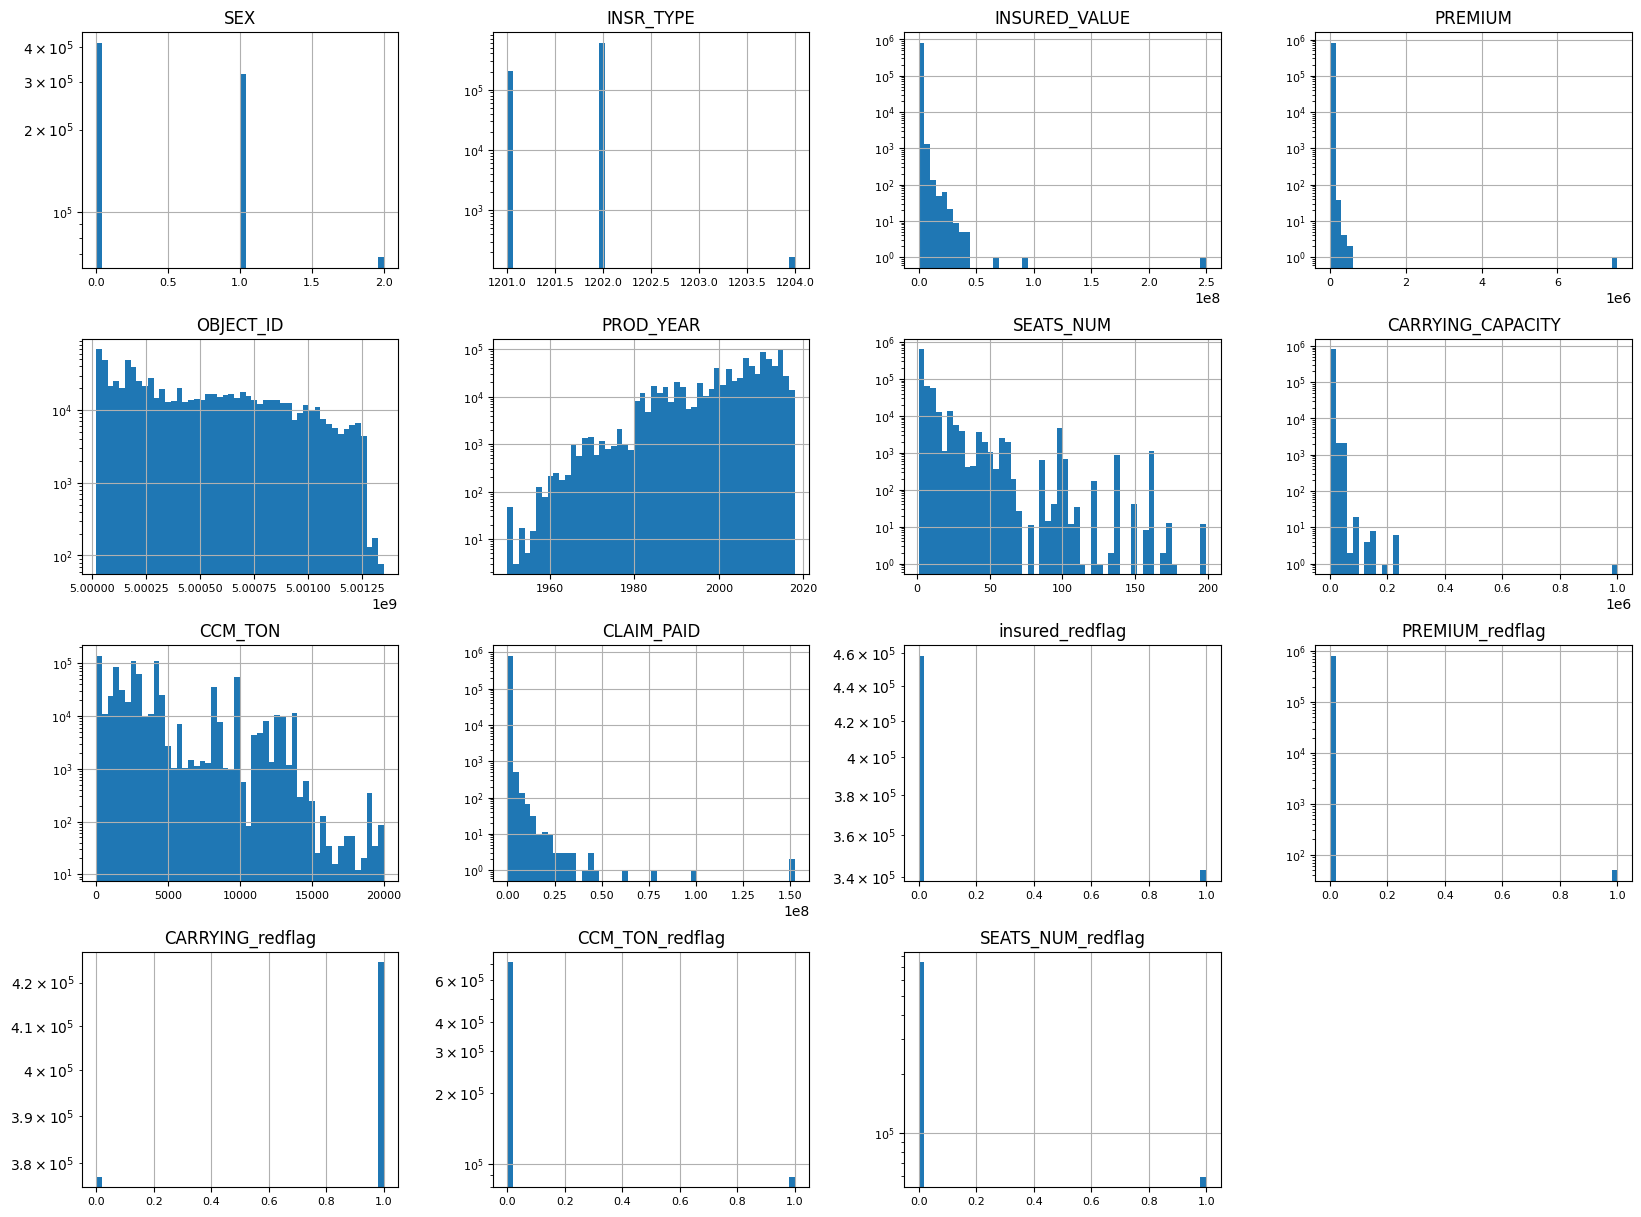

In [50]:
full_df.hist(figsize=(20,15), bins=50, xlabelsize=8, ylabelsize=8, log=True)

In [51]:
#frecuency of claims per policy
(full_df['CLAIM_PAID']>0).mean()

np.float64(0.07495008523857448)

In [52]:
full_df.shape

(801867, 20)

In [53]:
full_df['INSR_BEGIN'] = pd.to_datetime(
    full_df['INSR_BEGIN'],
    format='%d-%b-%y',
    errors='coerce'
)

full_df['INSR_END'] = pd.to_datetime(
    full_df['INSR_END'],
    format='%d-%b-%y',
    errors='coerce'
)

full_df['begin_year'] = full_df['INSR_BEGIN'].dt.year

In [54]:
full_df[['INSR_BEGIN', 'INSR_END']].head()

,INSR_BEGIN,INSR_END
0,2013-08-08,2014-08-07
1,2012-08-08,2013-08-07
2,2011-08-08,2012-08-07
3,2011-07-08,2011-08-07
4,2013-08-08,2014-08-07


In [55]:
full_df['policy_duration'] = (full_df['INSR_END'] - full_df['INSR_BEGIN']).dt.days
full_df['has_claim'] = (full_df['CLAIM_PAID'] > 0).astype(int)
full_df['vehicle_age'] = full_df['begin_year'] - full_df['PROD_YEAR']

In [56]:
full_df['INSR_BEGIN'].isna().sum()

np.int64(0)

In [57]:
full_df['INSR_BEGIN'].min(), full_df['INSR_BEGIN'].max()

(Timestamp('2011-07-01 00:00:00'), Timestamp('2018-06-30 00:00:00'))

In [58]:
full_df['INSR_END'].isna().sum()

np.int64(0)

In [59]:
full_df['policy_duration'].describe()

,policy_duration
count,801867.000000
mean,351.347179
std,59.060964
min,0.000000
25%,364.000000
50%,364.000000
75%,364.000000
max,523.000000


In [60]:
(full_df['policy_duration']==0).value_counts()

,count
policy_duration,
False,801677
True,190


In [61]:
full_df[full_df['policy_duration']==0].head(20)

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
14595,0,2014-05-25,2014-05-25,1202,216048.72,790.63,5000019397,2013.0,2.0,2.0,...,0.0,1,0,0,0,0,2014,0,0,1.0
48019,0,2014-05-25,2014-05-25,1202,216048.72,575.00,5000069490,2013.0,2.0,2.0,...,0.0,1,0,0,0,0,2014,0,0,1.0
50374,0,2014-05-25,2014-05-25,1202,216048.72,661.25,5000069371,2013.0,2.0,2.0,...,0.0,1,0,0,0,0,2014,0,0,1.0
50375,0,2014-05-25,2014-05-25,1202,216048.72,661.25,5000069380,2013.0,2.0,2.0,...,0.0,1,0,0,0,0,2014,0,0,1.0
50377,0,2014-05-25,2014-05-25,1202,216048.72,575.00,5000069424,2013.0,4.0,2.0,...,0.0,1,0,0,0,1,2014,0,0,1.0
65012,0,2014-05-25,2014-05-25,1202,216048.72,628.13,5000069267,2013.0,2.0,2.0,...,0.0,1,0,0,0,0,2014,0,0,1.0
65013,0,2014-05-25,2014-05-25,1202,216048.72,431.25,5000069278,2013.0,2.0,2.0,...,0.0,1,0,0,1,0,2014,0,0,1.0
120379,1,2012-01-22,2012-01-22,1202,679305.00,196.30,5000176286,1985.0,2.0,15.0,...,0.0,1,0,0,0,0,2012,0,0,27.0
184473,0,2013-03-05,2013-03-05,1202,914418.45,492.06,5000241559,2003.0,11.0,15.0,...,0.0,0,0,1,0,0,2013,0,0,10.0
234408,0,2012-11-11,2012-11-11,1202,112350.00,75.00,5000399003,2010.0,4.0,35.0,...,0.0,1,0,0,0,1,2012,0,0,2.0


i will eliminnate policy_duration=0 since it is  adat problem and usually related with problems in other fields and thera are only 190 registers

In [62]:
full_df.shape

(801867, 24)

In [63]:
invalid_cases = pd.concat([
    invalid_cases,
    full_df[full_df['policy_duration'] == 0]
], ignore_index=True)

In [64]:
full_df = full_df[full_df["policy_duration"] > 0]


In [65]:
full_df.shape

(801677, 24)

In [66]:
full_df[full_df['policy_duration'] > 365]['policy_duration'].value_counts().head(10)

,count
policy_duration,
374,6
375,4
366,4
371,3
453,3
523,2
368,2
382,2
385,2


In [67]:
full_df[full_df['policy_duration'] > 365]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
2770,1,2014-03-19,2015-03-25,1202,500000.00,3551.200,5000023232,2007.0,27.0,27.00,...,0.00,1,0,0,0,0,2014,371,0,7.0
3512,1,2013-02-18,2014-05-17,1202,70000.00,1944.860,5000024879,1981.0,1.0,150.00,...,0.00,0,0,0,1,1,2013,453,0,32.0
6458,0,2014-03-20,2015-03-29,1202,514828.50,3546.200,5000023349,2007.0,27.0,27.00,...,0.00,0,0,0,0,0,2014,374,0,7.0
10767,1,2014-03-19,2015-03-25,1202,500000.00,3546.200,5000023231,2007.0,27.0,27.00,...,0.00,1,0,0,0,0,2014,371,0,7.0
11974,0,2014-03-20,2015-03-29,1202,514828.52,3546.200,5000023347,2007.0,27.0,27.00,...,0.00,0,0,0,0,0,2014,374,0,7.0
45926,0,2014-03-20,2015-03-29,1202,514828.52,3551.200,5000042307,2007.0,27.0,27.00,...,0.00,0,0,0,0,0,2014,374,0,7.0
58599,2,2014-03-19,2015-04-08,1202,300000.00,4613.840,5000074731,2000.0,1.0,230.50,...,343390.08,0,0,0,1,1,2014,385,1,14.0
58604,2,2014-03-19,2015-04-08,1202,1200000.00,20864.360,5000074726,1999.0,1.0,165.00,...,343390.08,0,0,0,0,0,2014,385,1,15.0
93054,1,2011-11-08,2013-04-14,1202,530000.00,15522.380,5000150143,1990.0,2.0,163.00,...,0.00,0,0,0,0,1,2011,523,0,21.0
93057,1,2011-11-08,2013-04-14,1202,80000.00,1211.840,5000150144,2004.0,1.0,230.00,...,0.00,0,0,0,1,1,2011,523,0,7.0


In [68]:
full_df['vehicle_age'].describe()

,vehicle_age
count,801677.000000
mean,10.141512
std,9.858838
min,-7.000000
25%,2.000000
50%,7.000000
75%,15.000000
max,68.000000


In [69]:
(full_df['vehicle_age']<0).sum()

np.int64(2990)

In [70]:
neg = full_df[full_df['vehicle_age'] < 0]

neg.shape[0] / full_df.shape[0]

0.0037296816548310604

In [71]:
neg['vehicle_age'].value_counts()

,count
vehicle_age,
-1.0,2385
-2.0,227
-3.0,179
-4.0,109
-5.0,61
-6.0,25
-7.0,4


In [72]:
full_df.shape

(801677, 24)

In [73]:
full_df[full_df['vehicle_age'] < -3]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
1115,1,2013-07-12,2014-07-11,1202,1610000.0,31717.410,5000025296,2017.0,1.0,149.2,...,5909922.48,0,0,0,1,0,2013,364,1,-4.0
1116,1,2012-07-12,2013-07-11,1202,1610000.0,29403.803,5000025296,2017.0,1.0,149.2,...,0.00,0,0,0,1,0,2012,364,0,-5.0
1117,1,2011-07-11,2012-07-10,1202,1610000.0,44739.695,5000025296,2017.0,1.0,149.2,...,0.00,0,0,0,1,0,2011,365,0,-6.0
1519,1,2012-11-14,2013-11-13,1202,500000.0,1852.050,5000031295,2016.0,1.0,226.0,...,0.00,1,0,0,1,1,2012,364,0,-4.0
1520,1,2011-11-14,2012-11-13,1202,500000.0,1851.800,5000031295,2016.0,1.0,226.0,...,0.00,1,0,0,1,1,2011,365,0,-5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287111,0,2014-05-22,2014-05-24,1202,257871.9,209.240,5000618905,2018.0,1.0,3.0,...,0.00,0,0,1,0,0,2014,2,0,-4.0
293535,0,2012-07-08,2013-07-07,1202,1300000.0,1057.427,5000049231,2017.0,2.0,136.0,...,0.00,1,0,1,0,0,2012,364,0,-5.0
293536,0,2011-07-08,2012-07-07,1202,1300000.0,1001.537,5000049231,2017.0,2.0,136.0,...,0.00,1,0,1,0,0,2011,365,0,-6.0
315244,0,2014-07-08,2015-07-07,1202,400000.0,6609.150,5000036254,2018.0,1.0,3.0,...,0.00,0,0,1,0,0,2014,364,0,-4.0


vehicle_age < -3 considered data inconsistence. -1 and -2 could be with the new released cars

In [74]:
invalid_cases = pd.concat([
    invalid_cases,
    full_df[full_df['vehicle_age'] <= -3]
], ignore_index=True)

In [75]:
full_df.shape

(801677, 24)

In [76]:
full_df = full_df[full_df['vehicle_age'] > -3]
full_df['vehicle_age'] = full_df['vehicle_age'].clip(lower=0)

In [77]:
full_df.shape

(801299, 24)

In [78]:
full_df['vehicle_age'].describe()

,vehicle_age
count,801299.000000
mean,10.151656
std,9.852595
min,0.000000
25%,2.000000
50%,7.000000
75%,15.000000
max,68.000000


In [79]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801299 entries, 0 to 802035
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   SEX                801299 non-null  int64         
 1   INSR_BEGIN         801299 non-null  datetime64[ns]
 2   INSR_END           801299 non-null  datetime64[ns]
 3   INSR_TYPE          801299 non-null  int64         
 4   INSURED_VALUE      801299 non-null  float64       
 5   PREMIUM            801299 non-null  float64       
 6   OBJECT_ID          801299 non-null  int64         
 7   PROD_YEAR          801299 non-null  float64       
 8   SEATS_NUM          801299 non-null  float64       
 9   CARRYING_CAPACITY  801299 non-null  float64       
 10  TYPE_VEHICLE       801299 non-null  object        
 11  CCM_TON            801299 non-null  float64       
 12  MAKE               801299 non-null  object        
 13  USAGE              801299 non-null  object       

In [80]:
full_df.duplicated().sum()

np.int64(303)

In [81]:
full_df = full_df.drop_duplicates()

In [82]:
full_df.shape

(800996, 24)

In [83]:
full_df.isnull().sum()

,0
SEX,0
INSR_BEGIN,0
INSR_END,0
INSR_TYPE,0
INSURED_VALUE,0
PREMIUM,0
OBJECT_ID,0
PROD_YEAR,0
SEATS_NUM,0
CARRYING_CAPACITY,0


In [84]:
full_df.to_csv('cleaned_vehicle_insurance_new.csv', index=False)

In [85]:
invalid_cases.to_csv('invalid_cases.csv', index=False)

In [86]:
full_df.isnull().sum()

,0
SEX,0
INSR_BEGIN,0
INSR_END,0
INSR_TYPE,0
INSURED_VALUE,0
PREMIUM,0
OBJECT_ID,0
PROD_YEAR,0
SEATS_NUM,0
CARRYING_CAPACITY,0


In [87]:
full_df[full_df['USAGE'].isnull()]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age


In [90]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

In [91]:
full_df[full_df['OBJECT_ID']==5001130894]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
770888,0,2017-05-28,2018-05-27,1202,400000.0,448.9,5001130894,2017.0,1.0,400.0,Trailers and semitrailers,9720.0,LOW BED SEMITRAILER\n,Own Goods,0.0,1,0,0,1,1,2017,364,0,0.0


In [93]:
full_df["MAKE"] = full_df["MAKE"].str.replace("\n", " ", regex=False)

In [94]:
full_df[full_df['OBJECT_ID']==5001130894]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
770888,0,2017-05-28,2018-05-27,1202,400000.0,448.9,5001130894,2017.0,1.0,400.0,Trailers and semitrailers,9720.0,LOW BED SEMITRAILER,Own Goods,0.0,1,0,0,1,1,2017,364,0,0.0


In [95]:
full_df.to_csv('cleaned_vehicle_insurance_new.csv', index=False)